# DBLP Topic Classification
Supervised classification of ~3M academic papers into 25 research topics using labels produced by the NMF clustering pipeline.

**Models compared:** Multinomial Naive Bayes, Decision Tree, Random Forest

**Label source:** `predicted_topic` column from `df_umap_labeled.parquet` (generated by `DSClustering_EX.ipynb`)

## Cell 1 — Imports

In [ ]:
import numpy as np
import pandas as pd
import joblib
import time
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive
# drive.mount('/content/drive')


## Cell 2 - Load Files

In [ ]:
from pathlib import Path

# BASE_DIR default (adjust if running in Colab)
BASE_DIR = Path('C:/Users/Santiago Reyes/Downloads/DSPROJCLASS')
# BASE_DIR = Path('/content/drive/MyDrive/dblp-ref')  # Google Colab
CLUSTER_DIR = BASE_DIR / 'Clustering'

## Cell 2 — Load Files

print('Loading TF-IDF matrix...')
X_tfidf = joblib.load(BASE_DIR / 'tfidf_matrix.pkl')

print('Loading TF-IDF vectorizer...')
vectorizer = joblib.load(BASE_DIR / 'tfidf_vectorizer.pkl')

print('Loading cluster labels...')
label_candidates = [
    CLUSTER_DIR / 'df_umap_labeled.parquet',
    BASE_DIR / 'df_umap_labeled.parquet'
 ]
labels_path = next((p for p in label_candidates if p.exists()), None)
if labels_path is None:
    raise FileNotFoundError(
        'Could not find df_umap_labeled.parquet. Expected one of:\n'
        + '\n'.join(str(p) for p in label_candidates)
        + '\n\nRun the final save cell in DSClustering_EX.ipynb to generate it.'
    )
df_labels = pd.read_parquet(labels_path)
print(f'Using labels file   : {labels_path}')

if 'predicted_topic' not in df_labels.columns:
    raise KeyError(
        "Missing 'predicted_topic' in df_umap_labeled.parquet. "
        f"Found columns: {list(df_labels.columns)}"
    )

print(f'\nTF-IDF matrix shape : {X_tfidf.shape}')
print(f'Labels rows         : {len(df_labels):,}')
assert X_tfidf.shape[0] == len(df_labels), 'Row counts do not match between TF-IDF and labels!'
print('Row counts match. Ready.')

# Load full metadata dataframe for hypothesis cells (12, 14, 15)
print('\nLoading full DBLP metadata...')
dblp_path = BASE_DIR / 'dblp_preprocessed.parquet'
if not dblp_path.exists():
    raise FileNotFoundError(f'dblp_preprocessed.parquet not found at {dblp_path}')
df = pd.read_parquet(dblp_path)
required_cols = {'title', 'abstract', 'venue', 'n_citation'}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    print(f'  Warning: Missing columns in df: {missing_cols}')
    print(f'   Available columns: {list(df.columns)}')
    print(f'   Cells 12, 14, 15 may be skipped or error.')
print(f'Loaded {len(df):,} papers with columns: {list(df.columns)}')


## Cell 3 — Extract Labels & Sanity Check

Class distribution across 25 topics:


,count
Numerical Methods,486528
Networking,166078
"Information Systems, Business",330650
Digital Image Processing,115500
Algorithms & Data Structures,149357
Machine Learning,79639
Data Science,151775
"Search Engine, Semantics",58061
Statistical Modeling,212829
Signal Processing,112983


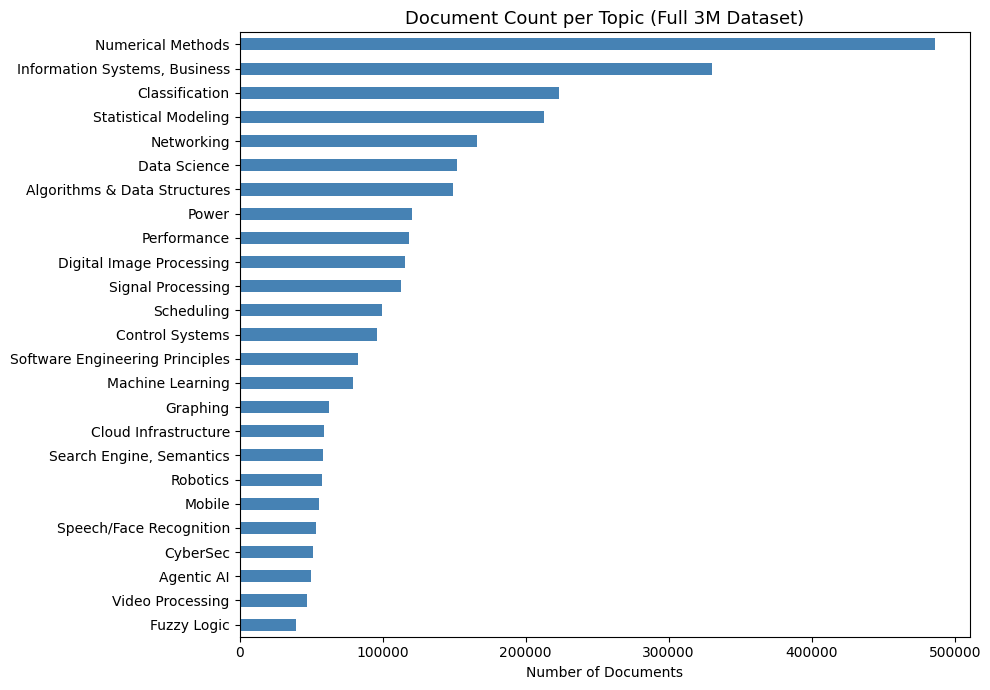

In [ ]:
TOPIC_NAMES = {
    0:  'Numerical Methods',
    1:  'Networking',
    2:  'Information Systems, Business',
    3:  'Digital Image Processing',
    4:  'Algorithms & Data Structures',
    5:  'Machine Learning',
    6:  'Data Science',
    7:  'Search Engine, Semantics',
    8:  'Statistical Modeling',
    9:  'Signal Processing',
    10: 'Fuzzy Logic',
    11: 'Cloud Infrastructure',
    12: 'Speech/Face Recognition',
    13: 'Control Systems',
    14: 'Power',
    15: 'Software Engineering Principles',
    16: 'Mobile',
    17: 'Agentic AI',
    18: 'Performance',
    19: 'Scheduling',
    20: 'Graphing',
    21: 'Video Processing',
    22: 'CyberSec',
    23: 'Classification',
    24: 'Robotics'
}

y_full = df_labels['predicted_topic'].to_numpy(dtype=np.int64)

counts = pd.Series(y_full).value_counts().sort_index()
counts.index = [TOPIC_NAMES[i] for i in counts.index]

print('Class distribution across 25 topics:')
display(counts.rename('count').to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Document Count per Topic (Full 3M Dataset)', fontsize=13)
ax.set_xlabel('Number of Documents')
plt.tight_layout()
plt.show()

## Cell 4 — Train/Test Split

> **Note on sampling:** The full dataset has ~3M documents. Naive Bayes handles this well, but Decision Tree and Random Forest would take too long so the size was set to `SAMPLE_SIZE = 300_000`. This is large enough to be representative while keeping each sweep run to minutes. Set to `None` to use the full dataset (NB only recommended in that case).

In [ ]:
SAMPLE_SIZE   = 300_000
RANDOM_STATE  = 42

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(y_full):
    print(f'Drawing stratified sample of {SAMPLE_SIZE:,} documents...')
    _, sample_idx = train_test_split(
        np.arange(len(y_full)),
        test_size=SAMPLE_SIZE / len(y_full),
        stratify=y_full,
        random_state=RANDOM_STATE
    )
    X_sample  = X_tfidf[sample_idx]
    y_sample  = np.asarray(y_full[sample_idx], dtype=np.int64)
else:
    sample_idx = np.arange(len(y_full))
    X_sample   = X_tfidf
    y_sample   = np.asarray(y_full, dtype=np.int64)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_sample, y_sample, sample_idx,
    test_size=0.2,
    stratify=np.asarray(y_sample, dtype=np.int64),
    random_state=RANDOM_STATE
)

print(f'Training set : {X_train.shape[0]:,} documents')
print(f'Test set     : {X_test.shape[0]:,} documents')
print(f'Features     : {X_train.shape[1]:,}')

Drawing stratified sample of 300,000 documents...
Training set : 240,000 documents
Test set     : 60,000 documents
Features     : 10,000


## Cell 5 — Helper Function for Evaluation

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label=''):
    """Fit model, return accuracy/F1/precision/recall/time plus predictions."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = round(time.time() - t0, 2)

    preds = model.predict(X_te)

    return {
        'label':           label,
        'accuracy':        accuracy_score(y_te, preds),
        'macro_f1':        f1_score(y_te, preds, average='macro', zero_division=0),
        'micro_f1':        f1_score(y_te, preds, average='micro', zero_division=0),
        'macro_precision': precision_score(y_te, preds, average='macro', zero_division=0),
        'macro_recall':    recall_score(y_te, preds, average='macro', zero_division=0),
        'train_time_s':    train_time,
        'model':           model,
        'preds':           preds,
    }


def results_to_row(r):
    return {k: v for k, v in r.items() if k not in ('model', 'preds')}


print('Helper functions defined.')

Helper functions defined.


## Cell 6 — Multinomial Naive Bayes Sweep

In [ ]:
alphas      = [0.01, 0.1, 0.5, 1.0]
nb_results  = []

for alpha in alphas:
    label = f'MNB  alpha={alpha}'
    print(f'Training {label} ...', end=' ', flush=True)
    res = evaluate_model(
        MultinomialNB(alpha=alpha),
        X_train, y_train, X_test, y_test,
        label=label
    )
    nb_results.append(res)
    print(f'Acc={res["accuracy"]:.4f}  Macro-F1={res["macro_f1"]:.4f}  Time={res["train_time_s"]}s')

nb_df = pd.DataFrame([results_to_row(r) for r in nb_results]).set_index('label')
print('\nMNB Summary Table:')
display(nb_df)

best_nb = max(nb_results, key=lambda r: r['macro_f1'])
print(f'\nBest MNB config: {best_nb["label"]}  (Macro-F1={best_nb["macro_f1"]:.4f})')

Training MNB  alpha=0.01 ... Acc=0.5543  Macro-F1=0.5397  Time=0.48s
Training MNB  alpha=0.1 ... Acc=0.5564  Macro-F1=0.5426  Time=0.37s
Training MNB  alpha=0.5 ... Acc=0.5582  Macro-F1=0.5421  Time=0.36s
Training MNB  alpha=1.0 ... Acc=0.5541  Macro-F1=0.5308  Time=0.35s

MNB Summary Table:


,accuracy,macro_f1,micro_f1,macro_precision,macro_recall,train_time_s
label,,,,,,
MNB alpha=0.01,0.554317,0.539680,0.554317,0.600559,0.519080,0.48
MNB alpha=0.1,0.556417,0.542642,0.556417,0.603717,0.522786,0.37
MNB alpha=0.5,0.558150,0.542113,0.558150,0.624023,0.515195,0.36
MNB alpha=1.0,0.554050,0.530778,0.554050,0.643761,0.495489,0.35



Best MNB config: MNB  alpha=0.1  (Macro-F1=0.5426)


## Cell 7 — Decision Tree Sweep

In [ ]:
dt_configs = [
    {'max_depth': 10,   'min_samples_split': 20},
    {'max_depth': 20,   'min_samples_split': 10},
    {'max_depth': 30,   'min_samples_split': 5},
    {'max_depth': None, 'min_samples_split': 20},
]

dt_results = []

for cfg in dt_configs:
    label = f'DT   depth={cfg["max_depth"]}  min_split={cfg["min_samples_split"]}'
    print(f'Training {label} ...', end=' ', flush=True)
    res = evaluate_model(
        DecisionTreeClassifier(random_state=RANDOM_STATE, **cfg),
        X_train, y_train, X_test, y_test,
        label=label
    )
    dt_results.append(res)
    print(f'Acc={res["accuracy"]:.4f}  Macro-F1={res["macro_f1"]:.4f}  Time={res["train_time_s"]}s')

# Build summary table
dt_df = pd.DataFrame([results_to_row(r) for r in dt_results]).set_index('label')
print('\nDecision Tree Summary Table:')
display(dt_df)

# Pick best DT and persist results
best_dt = max(dt_results, key=lambda r: r['macro_f1'])

from pathlib import Path
import joblib

BASE_DIR = globals().get('BASE_DIR', Path('C:/Users/Santiago Reyes/Downloads/DSPROJCLASS'))
DT_SUMMARY_PATH = BASE_DIR / 'dt_sweep_summary.parquet'
DT_CHECKPOINT_PATH = BASE_DIR / 'dt_sweep_checkpoint.joblib'

# Save summary as parquet for quick reload and analysis
try:
    dt_df.reset_index().to_parquet(DT_SUMMARY_PATH, index=False)
except Exception as e:
    print('Warning: failed to write parquet:', e)

# Save full sweep state (results + best model info)
try:
    joblib.dump({
        'dt_results': dt_results,
        'best_dt': best_dt,
        'dt_configs': dt_configs,
        'dt_summary_path': str(DT_SUMMARY_PATH),
    }, DT_CHECKPOINT_PATH)
except Exception as e:
    print('Warning: failed to write DT checkpoint:', e)

# Also update the general classification checkpoint with core variables
CHECKPOINT_PATH = BASE_DIR / 'classification_checkpoint.joblib'
checkpoint_vars = [
    'TOPIC_NAMES', 'df_labels', 'SAMPLE_SIZE', 'RANDOM_STATE', 'y_full',
    'sample_idx', 'X_sample', 'y_sample', 'X_train', 'X_test', 'y_train', 'y_test',
    'idx_train', 'idx_test', 'nb_results', 'dt_results', 'best_nb', 'best_dt',
]
checkpoint_state = {name: globals()[name] for name in checkpoint_vars if name in globals()}
try:
    joblib.dump(checkpoint_state, CHECKPOINT_PATH)
except Exception as e:
    print('Warning: failed to update general checkpoint:', e)

print(f'\\nBest DT config: {best_dt["label"]}  (Macro-F1={best_dt["macro_f1"]:.4f})')
print(f'Decision Tree summary saved to: {DT_SUMMARY_PATH}')
print(f'Decision Tree sweep checkpoint saved to: {DT_CHECKPOINT_PATH}')

Training DT   depth=10  min_split=20 ... Acc=0.4583  Macro-F1=0.3588  Time=74.44s
Training DT   depth=20  min_split=10 ... Acc=0.6031  Macro-F1=0.6357  Time=115.93s
Training DT   depth=30  min_split=5 ... Acc=0.6735  Macro-F1=0.7237  Time=225.1s
Training DT   depth=None  min_split=20 ... Acc=0.7406  Macro-F1=0.7641  Time=733.88s

Decision Tree Summary Table:


,accuracy,macro_f1,micro_f1,macro_precision,macro_recall,train_time_s
label,,,,,,
DT depth=10 min_split=20,0.458267,0.358837,0.458267,0.735924,0.336594,74.44
DT depth=20 min_split=10,0.603100,0.635728,0.603100,0.786264,0.574843,115.93
DT depth=30 min_split=5,0.673483,0.723745,0.673483,0.807916,0.673258,225.10
DT depth=None min_split=20,0.740550,0.764130,0.740550,0.775821,0.753549,733.88



Best DT config: DT   depth=None  min_split=20  (Macro-F1=0.7641)


In [ ]:
from pathlib import Path
import joblib

BASE_DIR = globals().get('BASE_DIR', Path('C:/Users/Santiago Reyes/Downloads/DSPROJCLASS'))
CHECKPOINT_PATH = BASE_DIR / 'classification_checkpoint.joblib'
checkpoint_vars = [
    'TOPIC_NAMES',
    'df_labels',
    'SAMPLE_SIZE',
    'RANDOM_STATE',
    'y_full',
    'sample_idx',
    'X_sample',
    'y_sample',
    'X_train',
    'X_test',
    'y_train',
    'y_test',
    'idx_train',
    'idx_test',
    'nb_results',
    'dt_results',
    'best_nb',
    'best_dt',
    'rf_results',
    'best_rf',
    'all_results',
    'metrics_df',
    'best_overall',
]

checkpoint_state = {name: globals()[name] for name in checkpoint_vars if name in globals()}
joblib.dump(checkpoint_state, CHECKPOINT_PATH)

print(f'Saved checkpoint with {len(checkpoint_state)} variables to: {CHECKPOINT_PATH}')
print('Reload later with: state = joblib.load(CHECKPOINT_PATH); globals().update(state)')


Saved checkpoint with 18 variables to: C:\Users\Santiago Reyes\Downloads\DSPROJCLASS\classification_checkpoint.joblib
Reload later with: state = joblib.load(CHECKPOINT_PATH); globals().update(state)


## Cell 8 — Random Forest Sweep

This is the slowest cell. Progress is printed after each configuration.

In [ ]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

BASE_DIR = globals().get('BASE_DIR', Path('C:/Users/Santiago Reyes/Downloads/DSPROJCLASS'))
STATE_CHECKPOINT_PATH = BASE_DIR / 'classification_checkpoint.joblib'
RF_CHECKPOINT_PATH = BASE_DIR / 'rf_sweep_checkpoint.joblib'
RANDOM_STATE = globals().get('RANDOM_STATE', 42)
RF_TRAIN_SIZE = int(globals().get('RF_TRAIN_SIZE', min(50_000, X_train.shape[0])))

required_names = ['X_train', 'X_test', 'y_train', 'y_test', 'RANDOM_STATE']
missing_names = [name for name in required_names if name not in globals()]
if missing_names and STATE_CHECKPOINT_PATH.exists():
    restored_state = joblib.load(STATE_CHECKPOINT_PATH)
    globals().update(restored_state)
    missing_names = [name for name in required_names if name not in globals()]

if missing_names:
    raise RuntimeError(
        'RF sweep cannot start because these prerequisites are missing: ' + ', '.join(missing_names) +
        f'. Run cells 2-7 first, or restore a valid checkpoint from {STATE_CHECKPOINT_PATH}.'
    )

if X_train.shape[0] != len(y_train) or X_test.shape[0] != len(y_test):
    raise ValueError('Train/test row counts do not match the label arrays.')
if X_train.shape[1] != X_test.shape[1]:
    raise ValueError('Train/test feature counts do not match.')
if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
    raise ValueError('Need at least two classes in both train and test splits.')

if 'evaluate_model' not in globals():
    def evaluate_model(model, X_tr, y_tr, X_te, y_te, label=''):
        """Fit model, return accuracy/F1/precision/recall/time plus predictions."""
        t0 = time.time()
        model.fit(X_tr, y_tr)
        train_time = round(time.time() - t0, 2)

        preds = model.predict(X_te)

        return {
            'label':           label,
            'accuracy':        accuracy_score(y_te, preds),
            'macro_f1':        f1_score(y_te, preds, average='macro', zero_division=0),
            'micro_f1':        f1_score(y_te, preds, average='micro', zero_division=0),
            'macro_precision': precision_score(y_te, preds, average='macro', zero_division=0),
            'macro_recall':    recall_score(y_te, preds, average='macro', zero_division=0),
            'train_time_s':    train_time,
            'model':           model,
            'preds':           preds,
        }

if 'results_to_row' not in globals():
    def results_to_row(r):
        return {k: v for k, v in r.items() if k not in ('model', 'preds')}

rf_train_size = min(RF_TRAIN_SIZE, X_train.shape[0])
if rf_train_size < X_train.shape[0]:
    rf_train_idx, _ = train_test_split(
        np.arange(X_train.shape[0]),
        train_size=rf_train_size,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
    X_train_rf = X_train[rf_train_idx]
    y_train_rf = y_train[rf_train_idx]
else:
    X_train_rf = X_train
    y_train_rf = y_train

print(f'RF preflight passed. Using {X_train_rf.shape[0]:,} training rows for the sweep...')

smoke_n = min(2000, X_train_rf.shape[0], X_test.shape[0])
print(f'Running a smoke test on {smoke_n:,} rows before the full sweep...')
smoke_result = evaluate_model(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, n_estimators=10, max_depth=5, min_samples_leaf=2, max_samples=0.5),
    X_train_rf[:smoke_n], y_train_rf[:smoke_n], X_test[:smoke_n], y_test[:smoke_n],
    label='RF smoke test'
)
print(f'Smoke test OK: Acc={smoke_result["accuracy"]:.4f}  Macro-F1={smoke_result["macro_f1"]:.4f}')

rf_configs = [
    {'n_estimators': 50,  'max_depth': 12, 'min_samples_leaf': 2, 'max_samples': 0.5},
    {'n_estimators': 100, 'max_depth': 16, 'min_samples_leaf': 2, 'max_samples': 0.5},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 4, 'max_samples': 0.5},
    {'n_estimators': 150, 'max_depth': 24, 'min_samples_leaf': 4, 'max_samples': 0.5},
]
rf_results = []

for i, cfg in enumerate(rf_configs, 1):
    label = f'RF   n_est={cfg["n_estimators"]}  depth={cfg["max_depth"]}  leaf={cfg["min_samples_leaf"]}'
    print(f'[{i}/{len(rf_configs)}] Training {label} ...', end=' ', flush=True)
    res = evaluate_model(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **cfg),
        X_train_rf, y_train_rf, X_test, y_test,
        label=label
    )
    rf_results.append(res)
    best_rf_so_far = max(rf_results, key=lambda r: r['macro_f1'])
    joblib.dump({
        'rf_results': rf_results,
        'best_rf_so_far': best_rf_so_far,
        'rf_configs': rf_configs,
        'rf_train_size': X_train_rf.shape[0],
    }, RF_CHECKPOINT_PATH)
    print(f'Acc={res["accuracy"]:.4f}  Macro-F1={res["macro_f1"]:.4f}  Time={res["train_time_s"]}s')

rf_df = pd.DataFrame([results_to_row(r) for r in rf_results]).set_index('label')
print('\nRandom Forest Summary Table:')
display(rf_df)

best_rf = max(rf_results, key=lambda r: r['macro_f1'])
joblib.dump({
    'rf_results': rf_results,
    'best_rf': best_rf,
    'rf_configs': rf_configs,
    'rf_train_size': X_train_rf.shape[0],
}, RF_CHECKPOINT_PATH)
print(f'\nBest RF config: {best_rf["label"]}  (Macro-F1={best_rf["macro_f1"]:.4f})')
print(f'RF sweep checkpoint saved to: {RF_CHECKPOINT_PATH}')

RF preflight passed. Using 50,000 training rows for the sweep...
Running a smoke test on 2,000 rows before the full sweep...
Smoke test OK: Acc=0.2260  Macro-F1=0.1176
[1/4] Training RF   n_est=50  depth=12  leaf=2 ... Acc=0.3806  Macro-F1=0.3007  Time=0.53s
[2/4] Training RF   n_est=100  depth=16  leaf=2 ... Acc=0.4850  Macro-F1=0.4617  Time=1.44s
[3/4] Training RF   n_est=100  depth=20  leaf=4 ... Acc=0.5581  Macro-F1=0.5535  Time=1.78s
[4/4] Training RF   n_est=150  depth=24  leaf=4 ... Acc=0.6167  Macro-F1=0.6314  Time=3.32s

Random Forest Summary Table:


,accuracy,macro_f1,micro_f1,macro_precision,macro_recall,train_time_s
label,,,,,,
RF n_est=50 depth=12 leaf=2,0.380650,0.300690,0.380650,0.781202,0.256908,0.53
RF n_est=100 depth=16 leaf=2,0.485017,0.461737,0.485017,0.815707,0.384433,1.44
RF n_est=100 depth=20 leaf=4,0.558067,0.553476,0.558067,0.826080,0.472436,1.78
RF n_est=150 depth=24 leaf=4,0.616683,0.631420,0.616683,0.837279,0.545327,3.32



Best RF config: RF   n_est=150  depth=24  leaf=4  (Macro-F1=0.6314)
RF sweep checkpoint saved to: C:\Users\Santiago Reyes\Downloads\DSPROJCLASS\rf_sweep_checkpoint.joblib


## Cell 9 — Master Comparison Table

In [ ]:
all_results = nb_results + dt_results + rf_results

metrics_df = pd.DataFrame([
    {
        'Model Config':      r['label'],
        'Accuracy':          round(r['accuracy'],        4),
        'Macro F1':          round(r['macro_f1'],        4),
        'Micro F1':          round(r['micro_f1'],        4),
        'Macro Precision':   round(r['macro_precision'], 4),
        'Macro Recall':      round(r['macro_recall'],    4),
        'Train Time (s)':    r['train_time_s'],
    }
    for r in all_results
])

metrics_df = metrics_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('Master Comparison Table (sorted by Macro F1):')
display(metrics_df)

best_overall = max(all_results, key=lambda r: r['macro_f1'])
print(f'\nBest overall model : {best_overall["label"]}')
print(f'  Accuracy         : {best_overall["accuracy"]:.4f}')
print(f'  Macro F1         : {best_overall["macro_f1"]:.4f}')
print(f'  Train time       : {best_overall["train_time_s"]}s')

Master Comparison Table (sorted by Macro F1):


,Model Config,Accuracy,Macro F1,Micro F1,Macro Precision,Macro Recall,Train Time (s)
0,DT depth=None min_split=20,0.7406,0.7641,0.7406,0.7758,0.7535,733.88
1,DT depth=30 min_split=5,0.6735,0.7237,0.6735,0.8079,0.6733,225.10
2,DT depth=20 min_split=10,0.6031,0.6357,0.6031,0.7863,0.5748,115.93
3,RF n_est=150 depth=24 leaf=4,0.6167,0.6314,0.6167,0.8373,0.5453,3.32
4,RF n_est=100 depth=20 leaf=4,0.5581,0.5535,0.5581,0.8261,0.4724,1.78
5,MNB alpha=0.1,0.5564,0.5426,0.5564,0.6037,0.5228,0.37
6,MNB alpha=0.5,0.5582,0.5421,0.5582,0.6240,0.5152,0.36
7,MNB alpha=0.01,0.5543,0.5397,0.5543,0.6006,0.5191,0.48
8,MNB alpha=1.0,0.5541,0.5308,0.5541,0.6438,0.4955,0.35
9,RF n_est=100 depth=16 leaf=2,0.4850,0.4617,0.4850,0.8157,0.3844,1.44



Best overall model : DT   depth=None  min_split=20
  Accuracy         : 0.7406
  Macro F1         : 0.7641
  Train time       : 733.88s


## Cell 10 — Confusion Matrix (Best Model)

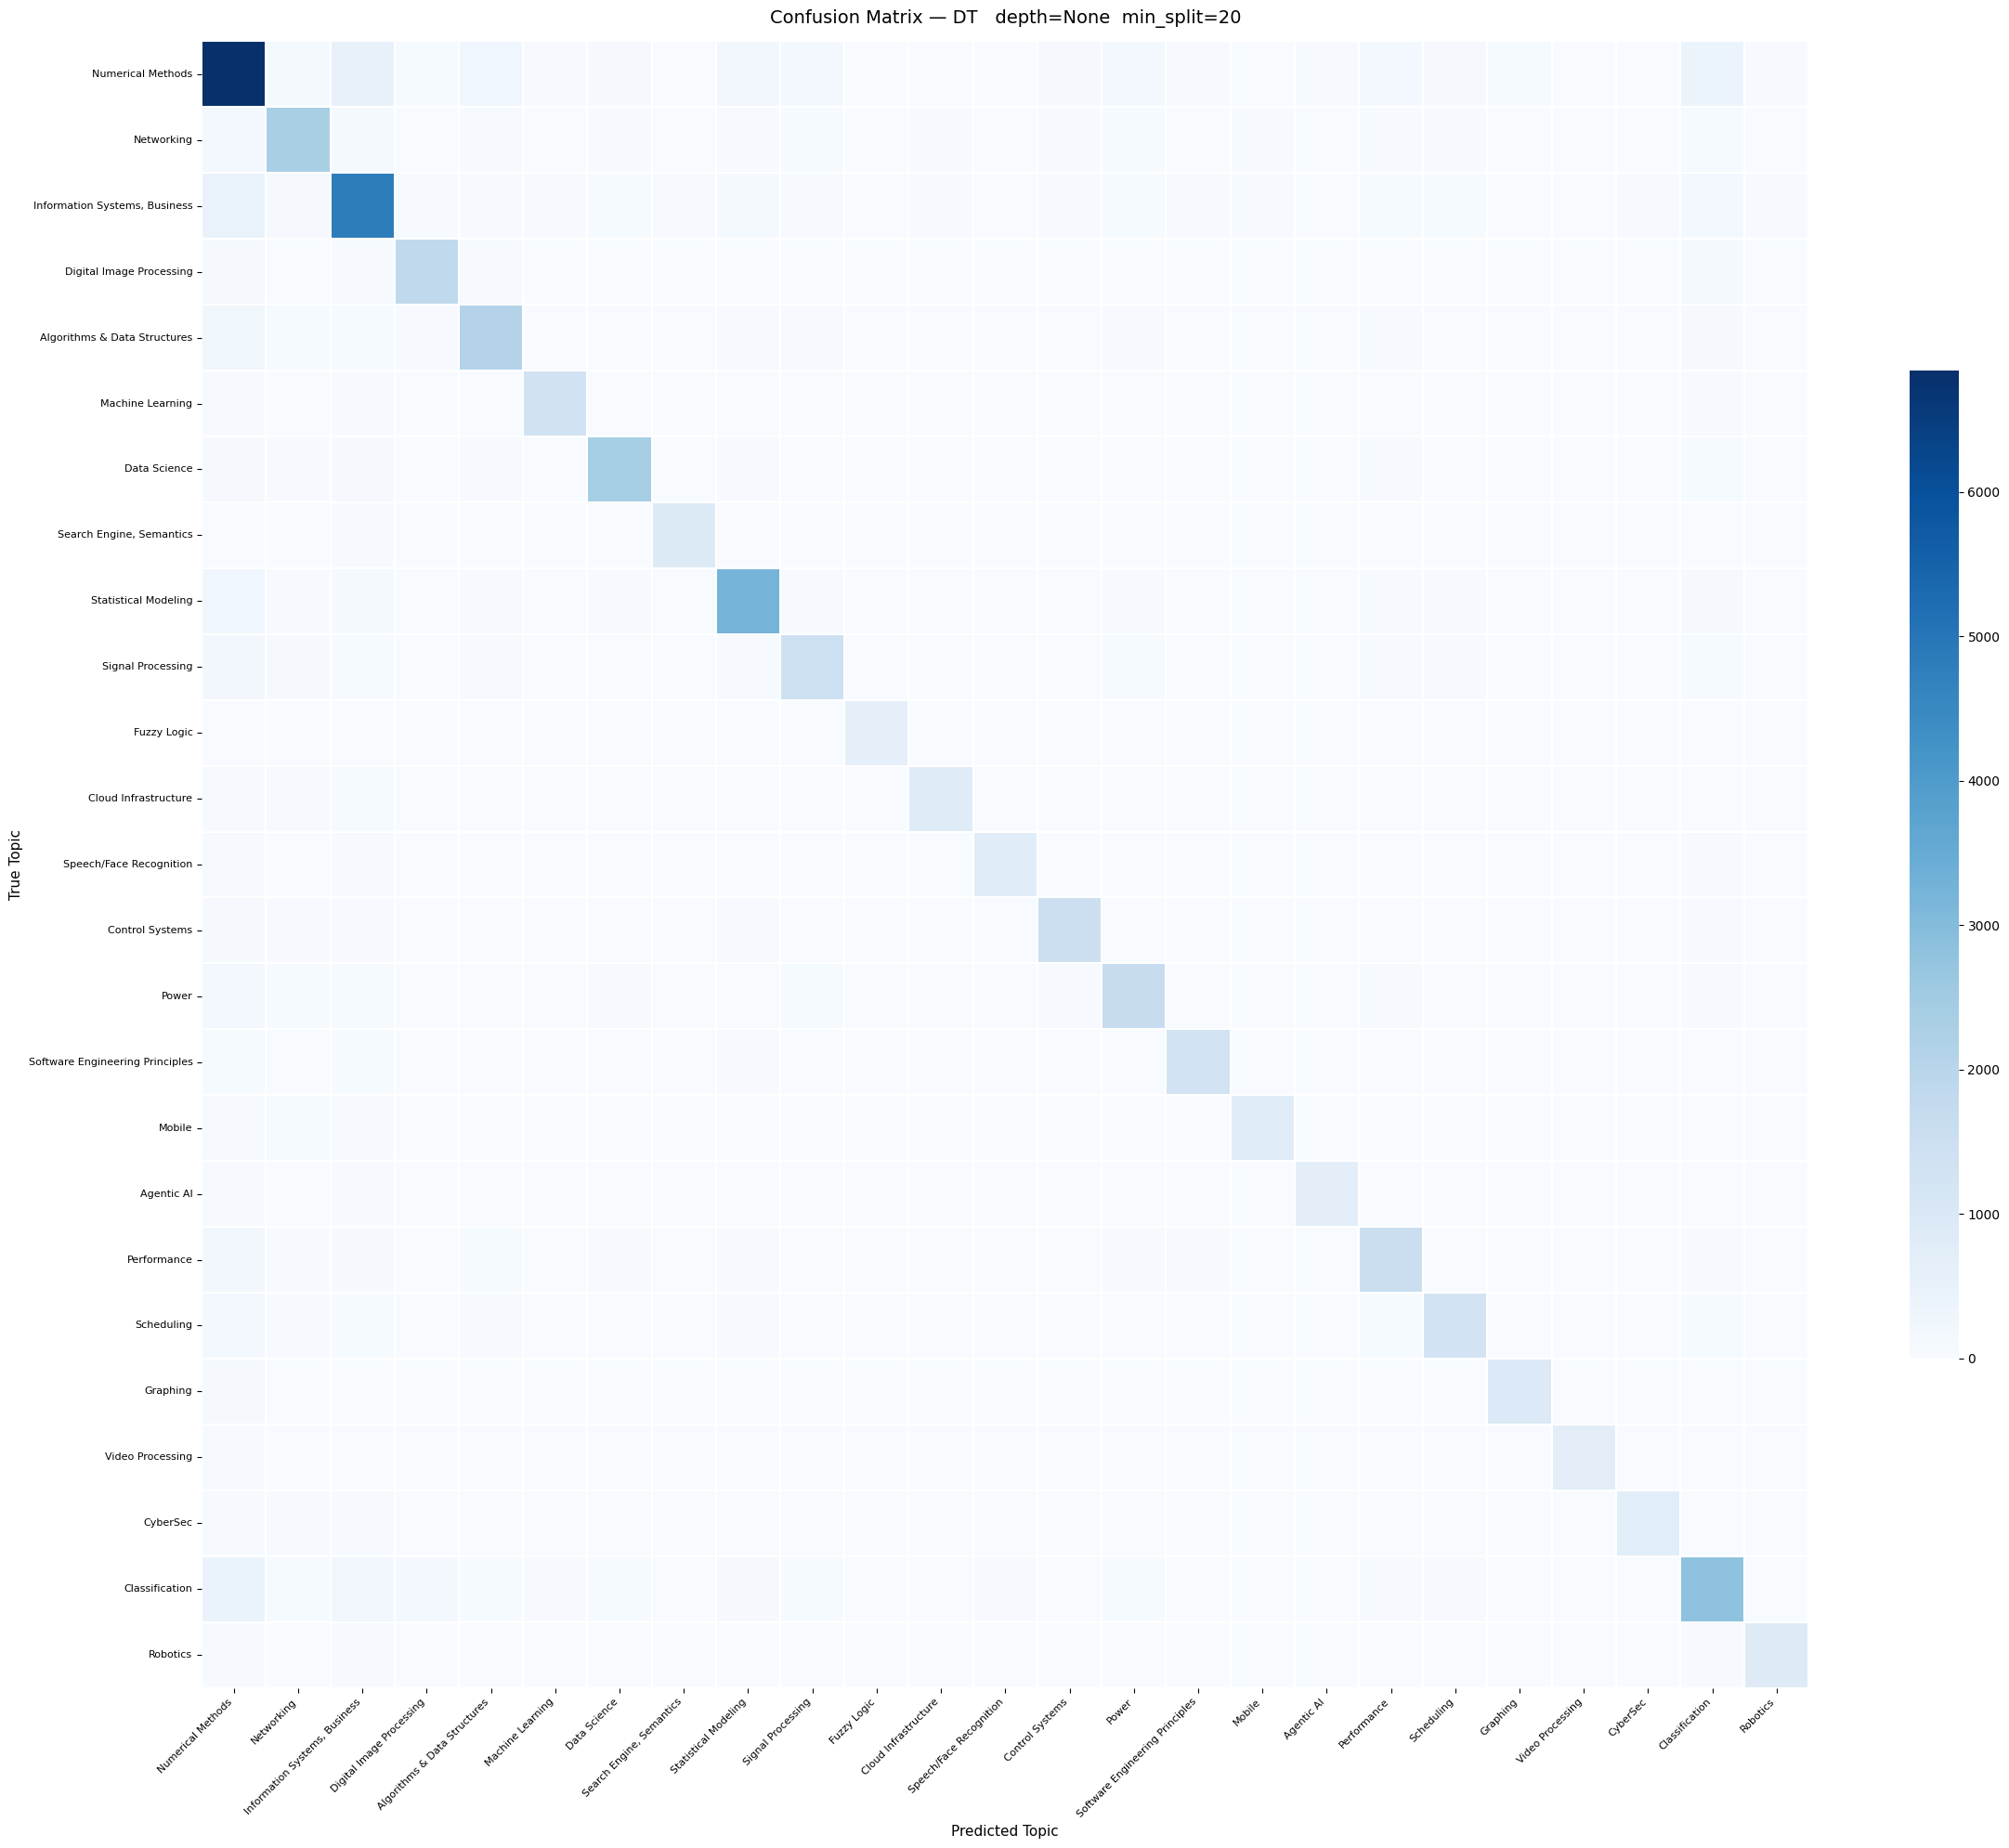


Per-class accuracy (diagonal):


,accuracy
Classification,0.6477
Scheduling,0.6565
Signal Processing,0.6567
Performance,0.6740
Power,0.6951
Agentic AI,0.7042
Algorithms & Data Structures,0.7203
Networking,0.7213
Numerical Methods,0.7213
Mobile,0.7296


In [ ]:
topic_labels = [TOPIC_NAMES[i] for i in range(25)]

cm = confusion_matrix(y_test, best_overall['preds'], labels=list(range(25)))

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=topic_labels,
    yticklabels=topic_labels,
    ax=ax,
    linewidths=0.2,
    cbar_kws={'shrink': 0.6},
    annot=True,
    fmt='d'
)
ax.set_title(f'Confusion Matrix — {best_overall["label"]}', fontsize=14, pad=14)
ax.set_xlabel('Predicted Topic', fontsize=11)
ax.set_ylabel('True Topic', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Per-class accuracy (diagonal / row sum)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_series = pd.Series(per_class_acc, index=topic_labels).sort_values()
print('\nPer-class accuracy (diagonal):')
display(acc_series.round(4).rename('accuracy').to_frame())

## Cell 11 — Per-Class F1 Bar Chart

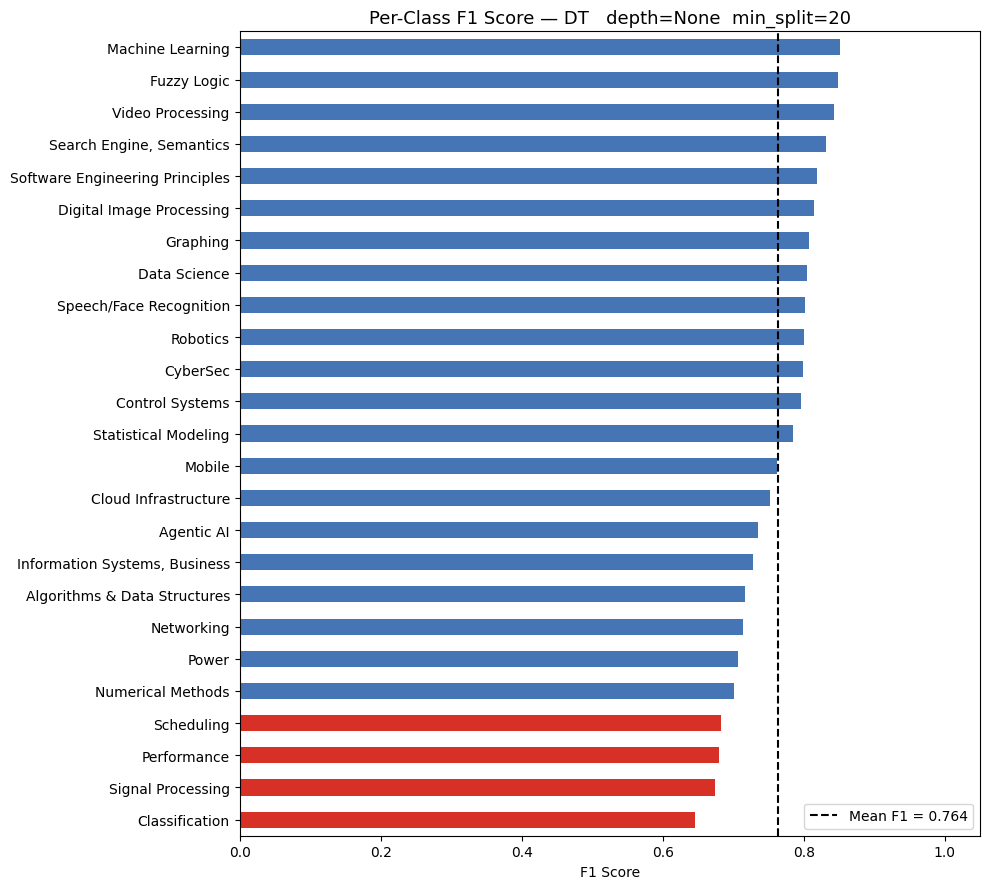

Easiest topics (top 5 F1):
Software Engineering Principles    0.8193
Search Engine, Semantics           0.8315
Video Processing                   0.8434
Fuzzy Logic                        0.8491
Machine Learning                   0.8510

Hardest topics (bottom 5 F1):
Classification       0.6455
Signal Processing    0.6743
Performance          0.6799
Scheduling           0.6833
Numerical Methods    0.7009


In [ ]:
from typing import Any

report_obj: Any = classification_report(
    y_test, best_overall['preds'],
    target_names=topic_labels,
    output_dict=True,
    zero_division=0
)
report_dict: dict[str, Any] = report_obj if isinstance(report_obj, dict) else {}

topic_f1_values: list[float] = []
for topic in topic_labels:
    topic_report: dict[str, Any] = report_dict.get(topic, {})
    topic_f1_values.append(float(topic_report.get('f1-score', 0.0)))

f1_series = pd.Series(topic_f1_values, index=topic_labels, dtype=float).sort_values()

colors = ['#d73027' if v < 0.7 else '#4575b4' for v in f1_series]

fig, ax = plt.subplots(figsize=(10, 9))
f1_series.plot(kind='barh', ax=ax, color=colors)
mean_f1: float = float(f1_series.mean())
ax.axvline(
    x=mean_f1, color='black', linestyle='--', linewidth=1.5,
    label=f'Mean F1 = {mean_f1:.3f}'
)
ax.set_title(f'Per-Class F1 Score — {best_overall["label"]}', fontsize=13)
ax.set_xlabel('F1 Score')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Easiest topics (top 5 F1):')
print(f1_series.tail(5).round(4).to_string())
print('\nHardest topics (bottom 5 F1):')
print(f1_series.head(5).round(4).to_string())

## Cell 12 — Hypothesis 1: Do Venue Features Help?

Publication venues (e.g., *Journal of Machine Learning*, *CVPR*) carry strong topical signal. We TF-IDF the `venue` column separately, hstack it onto the existing TF-IDF matrix, and re-run the best Naive Bayes config on both feature sets to isolate the contribution of venue.

In [ ]:
if df is None or 'venue' not in df.columns:
    print('Skipping Cell 12: metadata dataframe is not loaded or missing "venue" column.')
    print("To run this cell, load a dataframe with a 'venue' column into variable df.")
else:
    # Pull venue text for the rows that ended up in train/test
    venue_train_texts = df.iloc[idx_train]['venue'].fillna('').astype(str).values
    venue_test_texts  = df.iloc[idx_test]['venue'].fillna('').astype(str).values

    venue_vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    venue_train_matrix = venue_vectorizer.fit_transform(venue_train_texts)
    venue_test_matrix  = venue_vectorizer.transform(venue_test_texts)

    X_train_aug = hstack([X_train, venue_train_matrix])
    X_test_aug  = hstack([X_test,  venue_test_matrix])

    # Use the best NB alpha for a clean apples-to-apples comparison
    best_alpha = float(best_nb['label'].split('alpha=')[1])

    print('Running NB on TF-IDF only...')
    res_base = evaluate_model(
        MultinomialNB(alpha=best_alpha),
        X_train, y_train, X_test, y_test,
        label='NB — TF-IDF only'
    )

    print('Running NB on TF-IDF + Venue...')
    res_aug = evaluate_model(
        MultinomialNB(alpha=best_alpha),
        X_train_aug, y_train, X_test_aug, y_test,
        label='NB — TF-IDF + Venue'
    )

    comparison = pd.DataFrame([
        {'Config': res_base['label'], 'Accuracy': round(res_base['accuracy'], 4),
         'Macro F1': round(res_base['macro_f1'], 4),
         'Macro Precision': round(res_base['macro_precision'], 4),
         'Macro Recall': round(res_base['macro_recall'], 4)},
        {'Config': res_aug['label'],  'Accuracy': round(res_aug['accuracy'],  4),
         'Macro F1': round(res_aug['macro_f1'],  4),
         'Macro Precision': round(res_aug['macro_precision'],  4),
         'Macro Recall': round(res_aug['macro_recall'],  4)},
    ])
    display(comparison)

    delta_f1  = res_aug['macro_f1']  - res_base['macro_f1']
    delta_acc = res_aug['accuracy']  - res_base['accuracy']
    print(f'\nDelta Macro F1  : {delta_f1:+.4f}')
    print(f'Delta Accuracy  : {delta_acc:+.4f}')
    if delta_f1 > 0:
        print('Venue features improve classification performance.')
    else:
        print('Venue features do not improve classification performance over TF-IDF alone.')

Running NB on TF-IDF only...
Running NB on TF-IDF + Venue...


,Config,Accuracy,Macro F1,Macro Precision,Macro Recall
0,NB — TF-IDF only,0.5564,0.5426,0.6037,0.5228
1,NB — TF-IDF + Venue,0.4971,0.4778,0.4814,0.5009



Delta Macro F1  : -0.0648
Delta Accuracy  : -0.0593
Venue features do not improve classification performance over TF-IDF alone.


## Cell 13 — Hypothesis 2: What Keywords Drive Each Topic?

We pull `feature_importances_` from the best tree-based model (RF or DT), then for 5 focus topics (2 easiest + 3 hardest from Cell 11) we rank features by a combined score: **global importance × mean TF-IDF within that class**. This surfaces words that are both globally discriminative and strongly present in the topic.

Feature importance source: DT   depth=None  min_split=20

Topic 10: Fuzzy Logic  (F1=0.849)
  Top keywords: fuzzy | model | data | algorithm | control | information | learning | time | networks | image

Topic 5: Machine Learning  (F1=0.851)
  Top keywords: learning | data | model | algorithm | information | networks | web | time | problem | classification

Topic 23: Classification  (F1=0.645)
  Top keywords: classification | detection | data | feature | image | algorithm | model | learning | information | method

Topic 9: Signal Processing  (F1=0.674)
  Top keywords: channel | information | time | data | algorithm | networks | model | power | detection | mobile

Topic 18: Performance  (F1=0.680)
  Top keywords: parallel | data | algorithm | model | memory | time | distributed | software | performance | systems


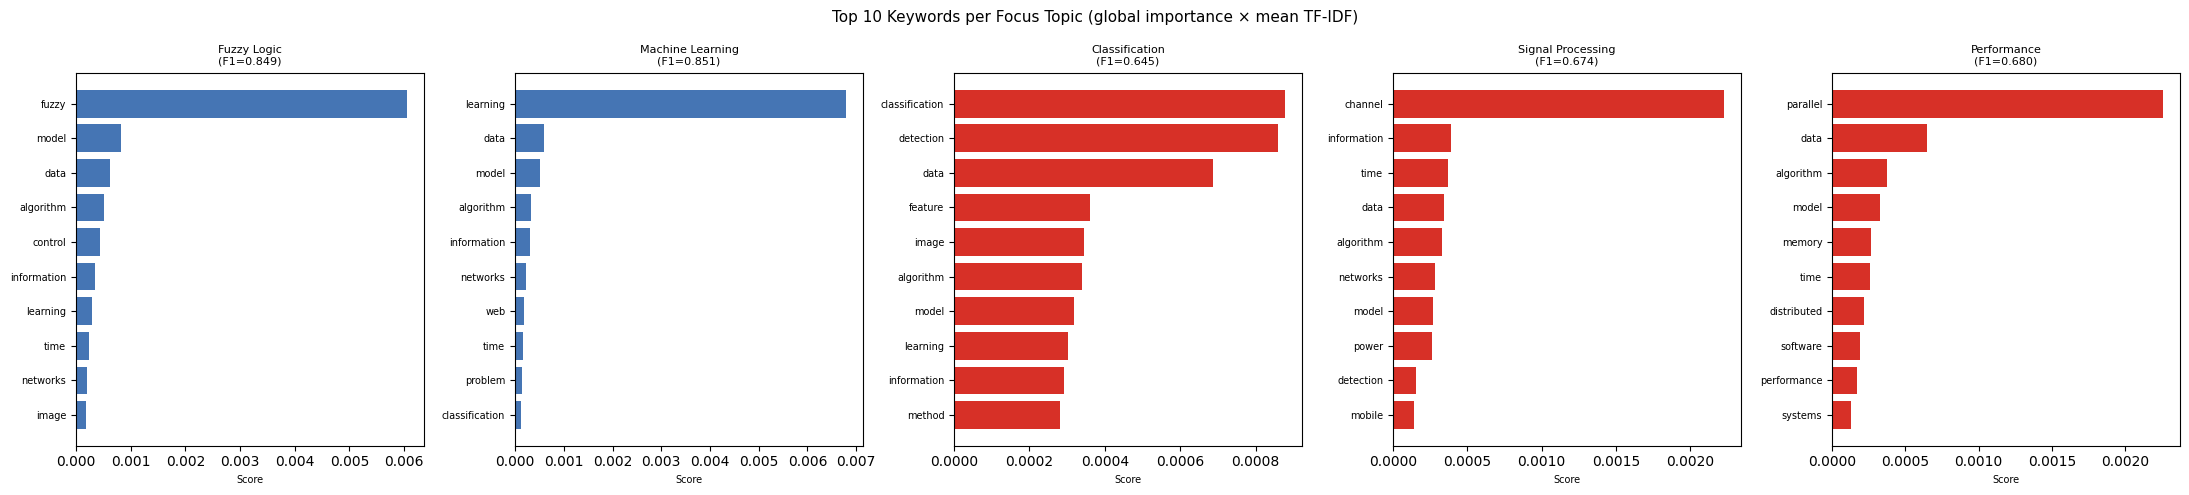

In [ ]:
feature_names = vectorizer.get_feature_names_out()

# Pick the better tree model
fi_model = best_rf if best_rf['macro_f1'] >= best_dt['macro_f1'] else best_dt
importances = fi_model['model'].feature_importances_
print(f'Feature importance source: {fi_model["label"]}')

# 2 easiest + 3 hardest topics from Cell 11
focus_topic_names = list(f1_series.index[-2:]) + list(f1_series.index[:3])
focus_topic_ids   = [k for name in focus_topic_names for k, v in TOPIC_NAMES.items() if v == name]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, topic_id, topic_name in zip(axes, focus_topic_ids, focus_topic_names):
    class_mask  = (y_train == topic_id)
    class_X     = X_train[class_mask]
    mean_tfidf  = np.asarray(class_X.mean(axis=0)).flatten()

    combined    = mean_tfidf * importances
    top10_idx   = np.argsort(combined)[::-1][:10]
    top10_words = feature_names[top10_idx]
    top10_scores = combined[top10_idx]

    # Print text summary
    f1_val = f1_series.get(topic_name, float('nan'))
    print(f'\nTopic {topic_id}: {topic_name}  (F1={f1_val:.3f})')
    print(f'  Top keywords: {" | ".join(top10_words)}')

    # Plot
    color = '#4575b4' if f1_val >= f1_series.mean() else '#d73027'
    ax.barh(top10_words[::-1], top10_scores[::-1], color=color)
    ax.set_title(f'{topic_name}\n(F1={f1_val:.3f})', fontsize=8)
    ax.set_xlabel('Score', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top 10 Keywords per Focus Topic (global importance × mean TF-IDF)', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 14 — Hypothesis 3: Do High-Citation Papers Cluster into Specific Topics?

The `n_citation` column is z-scored in the parquet (standardized across the full dataset). We group by predicted topic and compare mean and median citation count to see whether some research areas attract disproportionately more citations.

Citation statistics by topic (n_citation is z-scored):


,mean,median,count
topic_name,,,
Digital Image Processing,0.0362,-0.1472,115500
"Search Engine, Semantics",0.0277,-0.1472,58061
Algorithms & Data Structures,0.0271,-0.1219,149357
Data Science,0.0257,-0.1536,151775
Networking,0.0172,-0.1536,166078
Machine Learning,0.0064,-0.1726,79639
"Information Systems, Business",0.0037,-0.1726,330650
Classification,0.0034,-0.1599,223596
Software Engineering Principles,0.0032,-0.1536,83051


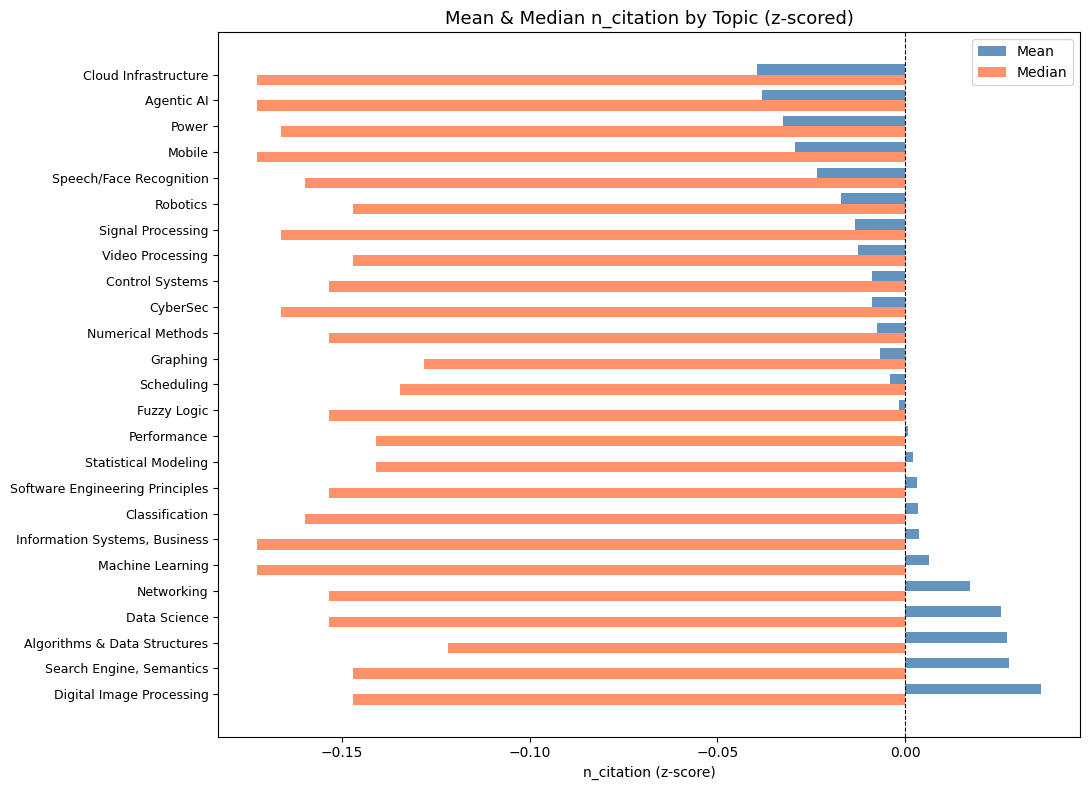


Top 5 highest-cited topics (by mean):
                                mean  median
topic_name                                  
Digital Image Processing      0.0362 -0.1472
Search Engine, Semantics      0.0277 -0.1472
Algorithms & Data Structures  0.0271 -0.1219
Data Science                  0.0257 -0.1536
Networking                    0.0172 -0.1536

Bottom 5 lowest-cited topics (by mean):
                           mean  median
topic_name                             
Speech/Face Recognition -0.0235 -0.1599
Mobile                  -0.0293 -0.1726
Power                   -0.0326 -0.1663
Agentic AI              -0.0380 -0.1726
Cloud Infrastructure    -0.0393 -0.1726


In [ ]:
if df is None or 'n_citation' not in df.columns:
    print('Skipping Cell 14: metadata dataframe is not loaded or missing "n_citation" column.')
    print("To run this cell, load a dataframe with an 'n_citation' column into variable df.")
else:
    df_analysis = df[['n_citation']].copy()
    df_analysis['topic']      = df_labels['predicted_topic'].astype(int).values
    df_analysis['topic_name'] = df_analysis['topic'].map(TOPIC_NAMES)

    citation_stats = (
        df_analysis.groupby('topic_name')['n_citation']
        .agg(mean='mean', median='median', count='count')
        .sort_values(by='mean', ascending=False)  # type: ignore[arg-type]
        .round(4)
    )

    print('Citation statistics by topic (n_citation is z-scored):')
    display(citation_stats)

    fig, ax = plt.subplots(figsize=(11, 8))
    x = np.arange(len(citation_stats))
    width = 0.4

    ax.barh(x + width/2, citation_stats['mean'],   width, label='Mean',   color='steelblue', alpha=0.85)
    ax.barh(x - width/2, citation_stats['median'], width, label='Median', color='coral',     alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(citation_stats.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Mean & Median n_citation by Topic (z-scored)', fontsize=13)
    ax.set_xlabel('n_citation (z-score)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('\nTop 5 highest-cited topics (by mean):')
    print(citation_stats.head(5)[['mean', 'median']].to_string())
    print('\nBottom 5 lowest-cited topics (by mean):')
    print(citation_stats.tail(5)[['mean', 'median']].to_string())

## Cell 15 — Case Studies: Misclassified Papers

We identify papers where the classifier was wrong and pull their title + abstract. These help explain *why* certain topic boundaries are blurry.

In [ ]:
required_case_cols = {'title', 'abstract', 'venue'}
if df is None or not required_case_cols.issubset(set(df.columns)):
    print('Skipping Cell 15: metadata dataframe is not loaded or missing required columns.')
    print(f"To run this cell, load a dataframe with {required_case_cols} into variable df.")
else:
    # Reconstruct test-set DataFrame with predictions
    test_df = df.iloc[idx_test][['title', 'abstract', 'venue']].copy()
    test_df['true_topic']       = y_test
    test_df['predicted_topic']  = best_overall['preds']
    test_df['true_name']        = test_df['true_topic'].map(TOPIC_NAMES)
    test_df['predicted_name']   = test_df['predicted_topic'].map(TOPIC_NAMES)

    misclassified = test_df[test_df['true_topic'] != test_df['predicted_topic']].copy()
    total_test    = len(test_df)
    n_wrong       = len(misclassified)

    print(f'Test set size        : {total_test:,}')
    print(f'Misclassified        : {n_wrong:,}  ({n_wrong / total_test:.1%})')
    print(f'Correctly classified : {total_test - n_wrong:,}  ({(total_test - n_wrong) / total_test:.1%})')

    # Focus on papers with non-empty abstracts for readable case studies
    rich = misclassified[misclassified['abstract'].str.len() > 100]
    cases = rich.sample(min(3, len(rich)), random_state=42)

    print(f'\n{"-"*70}')
    print('CASE STUDIES — Misclassified Papers')
    print(f'{"-"*70}')

    for i, (row_idx, row) in enumerate(cases.iterrows(), 1):
        print(f'\nCase {i}')
        print(f'  Title        : {row["title"]}')
        print(f'  Venue        : {row["venue"]}')
        abstract_snippet = str(row['abstract'])[:400] + ('...' if len(str(row['abstract'])) > 400 else '')
        print(f'  Abstract     : {abstract_snippet}')
        print(f'  True Topic   : {row["true_name"]}  (Topic {row["true_topic"]})')
        print(f'  Predicted    : {row["predicted_name"]}  (Topic {row["predicted_topic"]})')
        print()

    # Most confused topic pairs
    print('\nTop 10 most confused (true → predicted) pairs:')
    pair_counts = (
        misclassified
        .groupby(['true_name', 'predicted_name'])
        .size()
        .sort_values(ascending=False)
        .head(10)
        .rename('count')
        .reset_index()
    )
    display(pair_counts)

Test set size        : 60,000
Misclassified        : 15,567  (25.9%)
Correctly classified : 44,433  (74.1%)

----------------------------------------------------------------------
CASE STUDIES — Misclassified Papers
----------------------------------------------------------------------

Case 1
  Title        : EXPERIENCES WITH AN ON-LINE TRANSLATING DIALOGUE SYSTEM
  Venue        : meeting of the association for computational linguistics
  Abstract     : An English-Japanese bi-directional machine translation system was connected to a keyboard conversation function on a workstation, and tested via a satellite link with users in Japan and Switzerland. The set-up is described, and some informal observations on the nature of the bilingual dialogues reported.
  True Topic   : Numerical Methods  (Topic 0)
  Predicted    : Information Systems, Business  (Topic 2)


Case 2
  Title        : A data-driven analysis to question epidemic models for citation cascades on the blogosphere
  Venue      

,true_name,predicted_name,count
0,Numerical Methods,"Information Systems, Business",524
1,"Information Systems, Business",Numerical Methods,506
2,Classification,Numerical Methods,451
3,Numerical Methods,Classification,395
4,Algorithms & Data Structures,Numerical Methods,284
5,Numerical Methods,Algorithms & Data Structures,265
6,Statistical Modeling,Numerical Methods,264
7,Classification,"Information Systems, Business",215
8,Numerical Methods,Statistical Modeling,210
9,Performance,Numerical Methods,206
